# **Hilbert变换**

In [1]:
from scipy.fft import fft,ifft

import numpy as np
import random

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

import xcw_package as xcw

# 1 定义

In [2]:
def Hilbert(x):
    fft_x = fft(x)
    positive = fft_x[:len(fft_x)//2]*2#取正部乘2
    negative=fft_x[len(fft_x)//2:]*0#取负部乘0
    fft_s = np.concatenate((positive,negative))#得解析信号的频谱
    fft_s[0]=fft_x[0]
    hat_x=np.imag(ifft(fft_s))#取解析信号的虚部得到原始信号的希尔伯特变换
    return hat_x

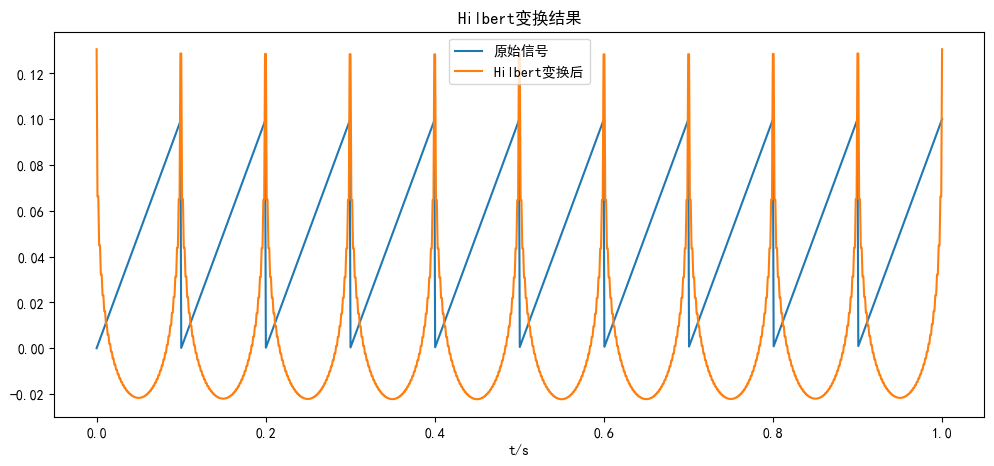

In [6]:
t=np.linspace(0,1,1000)
#生成三角波
def triangle_wave(t,f):
    t=t%(1/f)
    data=np.where(t<0.5,t,1-t)
    return data
x=triangle_wave(t,10)
hat_x=Hilbert(x)
 
plt.figure(figsize=(12,5))
plt.plot(t,x,label='原始信号')
plt.plot(t,hat_x,label='Hilbert变换后')
plt.xlabel('t/s')
plt.legend()
plt.title('Hilbert变换结果')
plt.show()

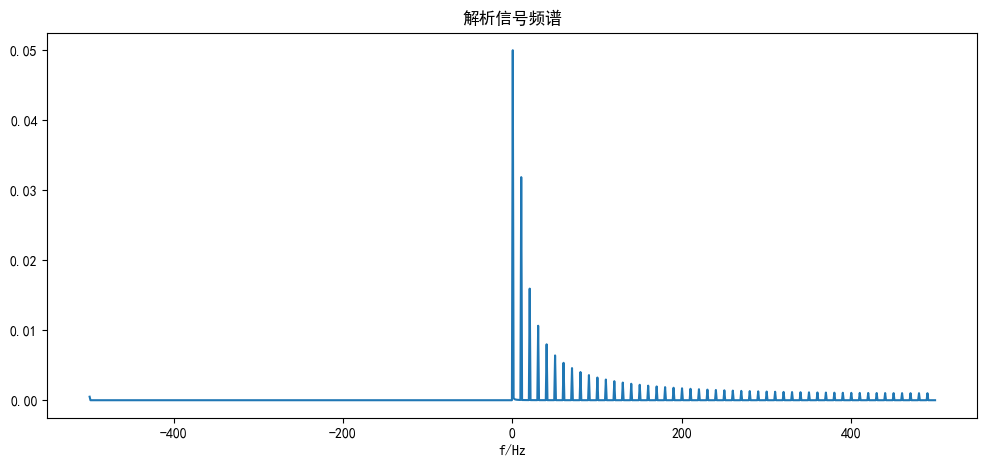

In [7]:
f=np.linspace(-0.5/(t[1]-t[0]),0.5/(t[1]-t[0]),len(t))
s=x+1j*hat_x
fft_s=fft(s)/len(s)
fft_s=np.fft.fftshift(fft_s)
plt.figure(figsize=(12,5))
plt.plot(f,np.abs(fft_s))
plt.xlabel('f/Hz')
plt.title('解析信号频谱')
plt.show()

# 2 解调原理

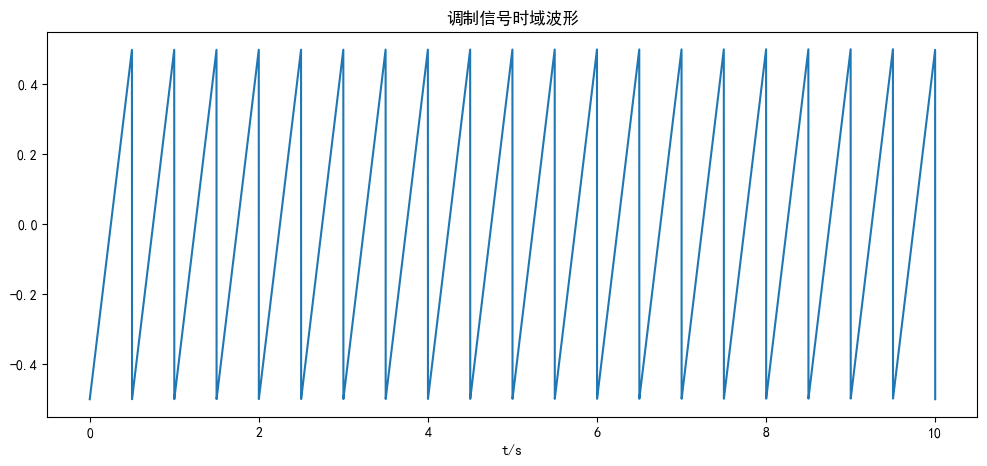

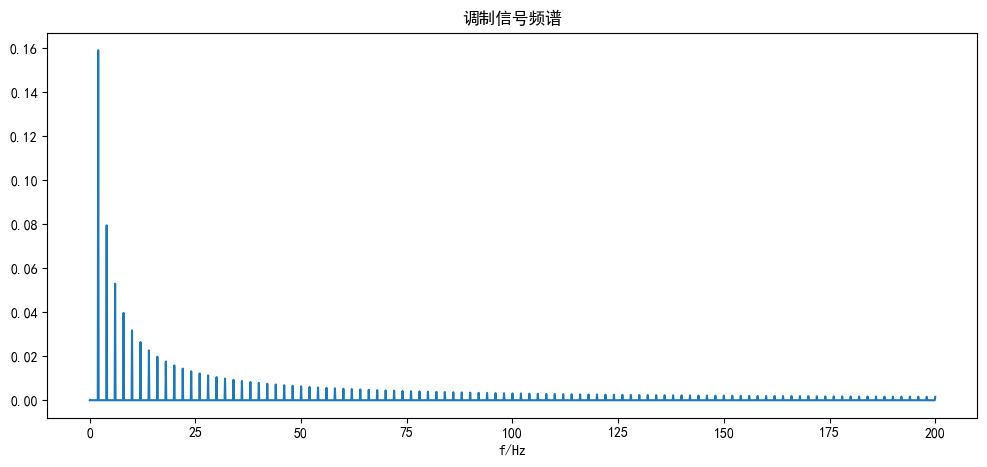

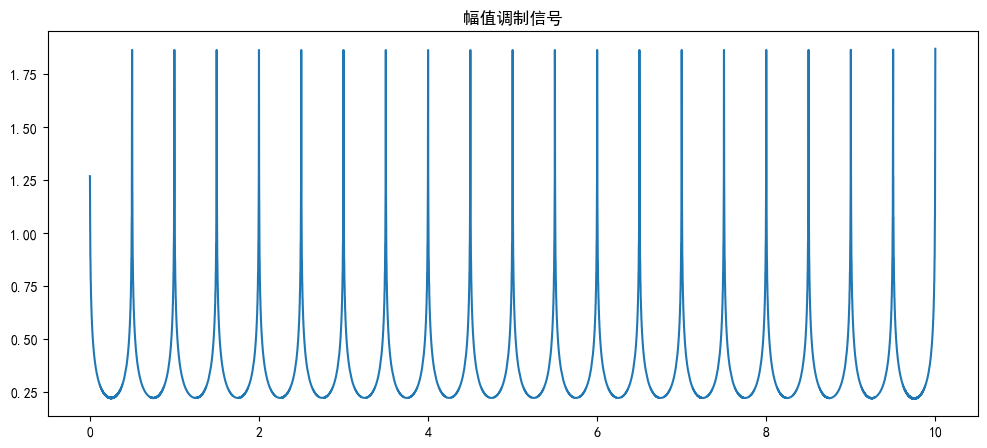

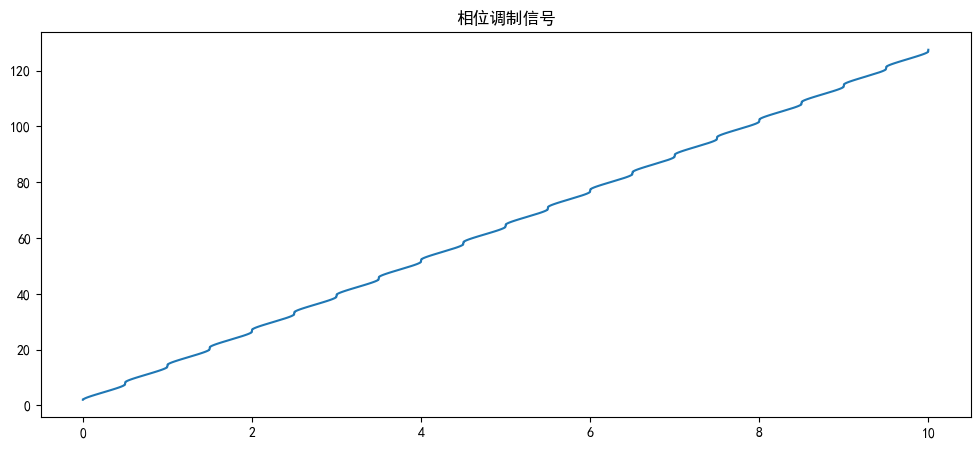

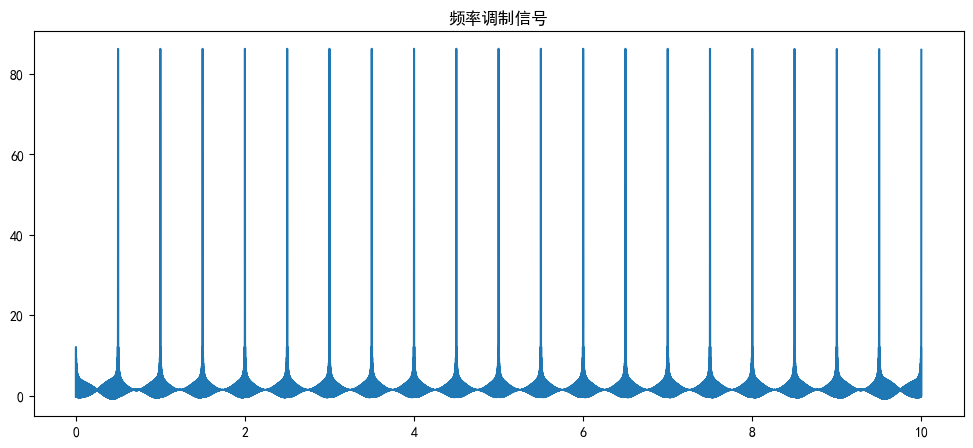

In [8]:
t=np.linspace(0,10,10000)
x1=3*np.cos(2*np.pi*21*t)
x2=5*np.cos(2*np.pi*23*t)
x3=2*np.cos(2*np.pi*25*t)
def func(t):#锯齿波
    return 2*(t%0.5)-0.5

x=func(t)
s=x+Hilbert(x)*1j#旋转向量

modSig=xcw.Signal(x,dt=t[1]-t[0])
modSig.plot(title='调制信号时域波形')
xcw.plot_fft(modSig,f_scope=(0,200),title='调制信号频谱')

_A=np.abs(s)
plt.figure(figsize=(12,5))
plt.plot(t,_A)
plt.title('幅值调制信号')
plt.show()

_phi=np.unwrap(np.angle(s))
plt.figure(figsize=(12,5))
plt.plot(t,_phi)
plt.title('相位调制信号')
plt.show()
_fre=np.diff(_phi)/(2*np.pi*(t[1]-t[0]))
plt.figure(figsize=(12,5))
plt.plot(t[1:],_fre)
plt.title('频率调制信号')
plt.show()
